# vulnRadar — Results Analysis

Report on the matches produced by **vulnRadar**: which tracked repositories later
had a CVE published, how many days after their selection, and how those CVEs are
classified (severity, CVSS, exploitability, CWE).

Data source: `Data/vulnRadar.db` (tables `tracked_repos` and `cve_matches`).

**Sections**
1. Selected repositories (overview per task)
2. Per-repo summary of CVE matches
3. Full match detail (one row per repo/CVE pair)
4. CVE classification
5. Time from selection to CVE — charts

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator

# Path relative to this notebook's folder.
DB = Path('Data') / 'vulnRadar.db'

conn = sqlite3.connect(DB)
df_repos = pd.read_sql_query('SELECT * FROM tracked_repos', conn)
df_matches = pd.read_sql_query('SELECT * FROM cve_matches', conn)
conn.close()

# Matches without a severity are shown as 'n/a' everywhere below.
df_matches['severity'] = df_matches['severity'].fillna('n/a')

print(f'Tracked repos: {len(df_repos):,}')
print(f'CVE matches:   {len(df_matches):,} '
      f'on {df_matches["repo_full_name"].nunique()} distinct repos')

Tracked repos: 4,908
CVE matches:   622 on 32 distinct repos


## 1. Selected repositories

How many repositories each selection task contributed, and over which period
they were selected.

In [2]:
task_overview = (
    df_repos.groupby('task')
    .agg(n_repos=('full_name', 'nunique'),
         first_selection=('selected_date', 'min'),
         last_selection=('selected_date', 'max'))
)
task_overview

,n_repos,first_selection,last_selection
task,,,
hot,65,2026-05-05,2026-07-21
official,111,2026-05-05,2026-07-21
talkers,1192,2026-05-05,2026-07-21


## 2. Repositories with at least one CVE match — summary

One row per matched repository:

- `n_cves`: distinct CVEs matched to the repo
- `first_match_days` / `last_match_days`: days between repo selection and CVE publication
- `max_severity`: worst severity among its CVEs
- `mean_cvss`: average CVSS score (ignores CVEs without a score)
- `task`, `score`: which vulnRadar task(s) selected the repo and the selection score

In [3]:
SEV_ORDER = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']


def max_severity(series):
    ranked = [s for s in series if s in SEV_ORDER]
    return max(ranked, key=SEV_ORDER.index) if ranked else 'n/a'


repo_summary = (
    df_matches.groupby('repo_full_name')
    .agg(n_cves=('cve_id', 'nunique'),
         first_match_days=('days_until_cve', 'min'),
         last_match_days=('days_until_cve', 'max'),
         max_severity=('severity', max_severity),
         mean_cvss=('cvss_score', 'mean'))
    .round({'mean_cvss': 1})
    .sort_values('n_cves', ascending=False)
)

# Add the selecting task(s) and score from tracked_repos.
task_info = (
    df_repos.groupby('full_name')
    .agg(task=('task', lambda s: ', '.join(sorted(set(s)))),
         score=('score', 'max'))
)
repo_summary = repo_summary.join(task_info)
repo_summary

,n_cves,first_match_days,last_match_days,max_severity,mean_cvss,task,score
repo_full_name,,,,,,,
openclaw/openclaw,175,0,73,CRITICAL,7.1,"official, talkers",212.0
ImageMagick/ImageMagick,74,6,71,HIGH,4.5,official,33.0
WWBN/AVideo,40,6,76,CRITICAL,6.6,official,31.0
FlowiseAI/Flowise,40,6,68,CRITICAL,7.8,official,23.0
MervinPraison/PraisonAI,35,8,35,CRITICAL,7.5,talkers,6.0
apache/airflow,33,6,69,CRITICAL,6.5,official,17.0
wolfSSL/wolfssl,32,51,51,CRITICAL,6.9,official,32.0
netty/netty,25,23,63,HIGH,7.0,official,22.0
MISP/MISP,21,3,30,HIGH,8.2,official,12.0


## 3. Full match detail

One row per (repository, CVE) pair, sorted by repo and days-until-CVE.

In [4]:
detail = (
    df_matches[['repo_full_name', 'cve_id', 'cve_published_date',
                'days_until_cve', 'severity', 'cvss_score',
                'exploitability_score', 'cwe_ids']]
    .sort_values(['repo_full_name', 'days_until_cve', 'cve_id'])
    .reset_index(drop=True)
)
with pd.option_context('display.max_rows', None):
    display(detail)

,repo_full_name,cve_id,cve_published_date,days_until_cve,severity,cvss_score,exploitability_score,cwe_ids
0,ChurchCRM/CRM,CVE-2026-42288,2026-05-12T23:16:17.600,7,CRITICAL,10.0,3.9,CWE-94
1,ChurchCRM/CRM,CVE-2026-42289,2026-05-12T23:16:17.730,7,HIGH,8.8,2.8,"CWE-269, CWE-306, CWE-352"
2,ChurchCRM/CRM,CVE-2026-44547,2026-05-12T23:16:18.610,7,CRITICAL,9.6,3.1,"CWE-287, CWE-304"
3,ChurchCRM/CRM,CVE-2026-44548,2026-05-12T23:16:18.750,7,HIGH,8.1,2.8,"CWE-352, CWE-650"
4,ChurchCRM/CRM,CVE-2026-58408,2026-07-13T20:16:49.770,69,MEDIUM,6.5,2.8,"CWE-862, CWE-863"
5,ChurchCRM/CRM,CVE-2026-58409,2026-07-13T21:16:48.450,69,CRITICAL,9.1,2.3,CWE-434
6,ChurchCRM/CRM,CVE-2026-58410,2026-07-13T21:16:48.573,69,HIGH,7.1,2.8,"CWE-639, CWE-862"
7,ChurchCRM/CRM,CVE-2026-58411,2026-07-13T22:16:48.270,69,n/a,NaN,NaN,CWE-79
8,FlowiseAI/Flowise,CVE-2026-43995,2026-05-11T18:16:37.660,6,n/a,NaN,NaN,CWE-918
9,FlowiseAI/Flowise,CVE-2026-42861,2026-06-08T16:16:39.503,34,n/a,NaN,NaN,"CWE-284, CWE-639, CWE-915"


## 4. CVE classification

Severity distribution, score statistics, and the most frequent CWE categories.
A match can carry several comma-separated CWEs: each one is counted once.

In [5]:
severity_counts = (
    detail['severity']
    .value_counts()
    .reindex(SEV_ORDER + ['n/a'], fill_value=0)
    .rename('n_matches')
)
print(severity_counts.to_string())
print()
print(detail[['cvss_score', 'exploitability_score']].describe().round(2))

severity
LOW          53
MEDIUM      227
HIGH        224
CRITICAL     37
n/a          81

       cvss_score  exploitability_score
count      541.00                541.00
mean         6.60                  2.77
std          1.83                  0.88
min          1.80                  0.30
25%          5.30                  2.20
50%          6.50                  2.80
75%          8.10                  3.90
max         10.00                  3.90


In [6]:
cwe_counts = (
    detail['cwe_ids']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .rename('n_matches')
)
cwe_counts.head(20)

cwe_ids
CWE-863    59
CWE-862    58
CWE-918    27
CWE-22     24
CWE-79     22
CWE-200    22
CWE-125    21
CWE-401    20
CWE-184    18
CWE-639    18
CWE-400    17
CWE-404    15
CWE-416    15
CWE-770    14
CWE-306    14
CWE-787    14
CWE-94     13
CWE-78     12
CWE-122    12
CWE-367    12
Name: n_matches, dtype: int64

## 5. Time from selection to CVE

Two views of `days_until_cve` (days between the repo being selected by vulnRadar
and a matching CVE being published):

- **Left — cumulative**: number of repos whose **first** match happened within
  *x* days of selection. Monotonic, reaches the total number of matched repos.
- **Right — first match per day, by task**: on day *x*, how many repos got their
  **first ever** match, split by the task that selected them. Each repo appears
  in exactly one bar (on the day of its first match) — but a repo selected by
  several tasks is counted once **per task**, so the bars can add up to more
  than the number of distinct repos.

Below the chart, a per-repo listing of the same first-match data: repo, day of
first match, and the task(s) that selected it — a plain grid broken down by
task and day would mostly be zeros at this dataset's size.

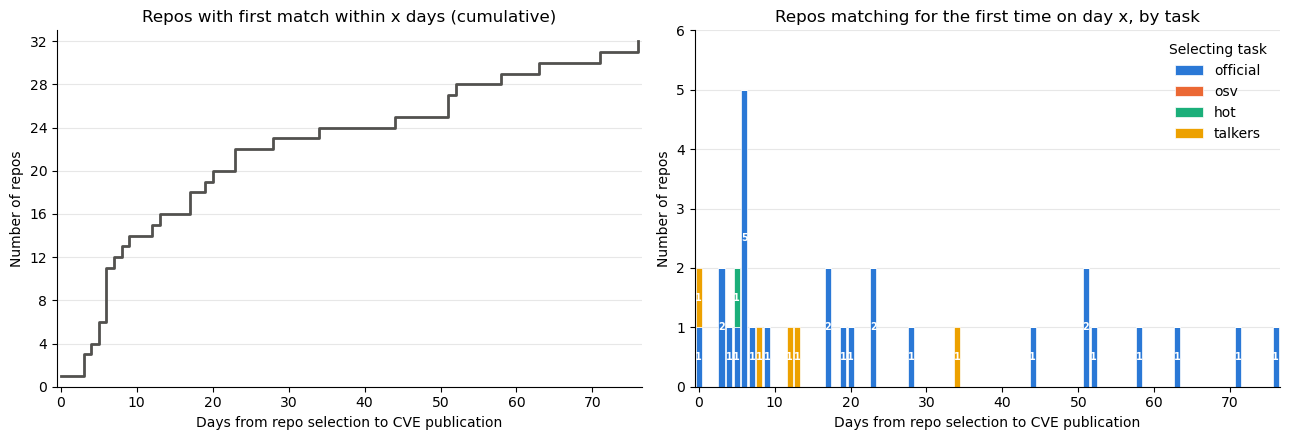

32 repos, each on the day of its FIRST CVE match after being selected (0 = matched the same day it was selected):


,days_after_selection_to_first_cve,selected_by_task
repo,,
openclaw/openclaw,0,"official, talkers"
MISP/MISP,3,official
axios/axios,3,official
open5gs/open5gs,4,official
StrTzz123/iot_vul,5,hot
pavel-odintsov/fastnetmon,5,official
WWBN/AVideo,6,official
FlowiseAI/Flowise,6,official
gpac/gpac,6,official


In [7]:
# Fixed colour per task: colour follows the task, never its rank in the chart.
TASK_COLORS = {'official': '#2a78d6', 'osv': '#eb6834',
               'hot': '#1baf7a', 'talkers': '#eda100'}
# Validated categorical order for stacked bars: blue, orange, aqua, yellow
# (slots 1-4). 'osv' was added after the original 3-task chart, at the
# previously-unused slot 2 — the other three tasks' colours are untouched.
# Placed here (not appended) so the dict's iteration order matches the
# validated adjacent-pair sequence the stack below relies on.

max_day = int(df_matches['days_until_cve'].max())
days = np.arange(0, max_day + 1)

# Day of the FIRST match of each repo.
first_match = df_matches.groupby('repo_full_name')['days_until_cve'].min()

# --- left: cumulative number of repos whose first match happened within x days
cumulative = [(first_match <= d).sum() for d in days]

# --- right: same first-match day, but broken down by selecting task.
# A repo selected by several tasks is counted once per task (by design).
repo_task = df_repos[['full_name', 'task']].drop_duplicates()
firsts_by_task = repo_task.join(first_match, on='full_name', how='inner')

first_by_task = (
    firsts_by_task
    .pivot_table(index='days_until_cve', columns='task',
                 values='full_name', aggfunc='count')
    .reindex(days, fill_value=0)
    .fillna(0)
    .reindex(columns=list(TASK_COLORS), fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].step(days, cumulative, where='post', color='#52514e', linewidth=2)
axes[0].set_title('Repos with first match within x days (cumulative)')
axes[0].set_ylim(0, len(first_match) + 1)

bottom = np.zeros(len(days))
for task, color in TASK_COLORS.items():
    heights = first_by_task[task].to_numpy()
    axes[1].bar(days, heights, bottom=bottom, width=0.8,
                color=color, label=task, edgecolor='white', linewidth=0.5)
    # Direct labels: the palette's lighter hues fall below 3:1 on white, so the
    # count is always readable without relying on colour alone.
    for x, h, b in zip(days, heights, bottom):
        if h > 0:
            axes[1].text(x, b + h / 2, int(h), ha='center', va='center',
                         fontsize=7, color='white', fontweight='bold')
    bottom += heights

axes[1].set_title('Repos matching for the first time on day x, by task')
axes[1].legend(frameon=False, title='Selecting task')
axes[1].set_ylim(0, bottom.max() + 1)

for ax in axes:
    ax.set_xlabel('Days from repo selection to CVE publication')
    ax.set_ylabel('Number of repos')
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlim(-0.5, max_day + 0.5)

plt.tight_layout()
plt.show()

# Table view (accessibility: never colour alone). A wide day-by-task grid is
# mostly zeros with this few repos — a compact per-repo listing carries the
# same information more legibly. Column names are spelled out here (rather
# than reusing the raw 'days_until_cve' / 'task' field names) so the table
# is self-explanatory without re-reading the markdown above it.
first_match_listing = (
    firsts_by_task
    .groupby('full_name')
    .agg(days_until_cve=('days_until_cve', 'first'),
         task=('task', lambda s: ', '.join(sorted(set(s)))))
    .rename_axis('repo')
    .rename(columns={'days_until_cve': 'days_after_selection_to_first_cve',
                     'task': 'selected_by_task'})
    .sort_values('days_after_selection_to_first_cve')
)
print(f'{len(first_match_listing)} repos, each on the day of its FIRST CVE match '
      f'after being selected (0 = matched the same day it was selected):')
first_match_listing